In [1]:
!pip install FDApy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import mnist
from FDApy.representation.functional_data import DenseFunctionalData, DenseArgvals, DenseValues
from FDApy.preprocessing import UFPCA
from FDApy.visualization import plot

2025-03-25 17:19:44.230427: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-25 17:19:44.516048: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-25 17:19:44.639862: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-25 17:19:45.290977: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: li

# Introduction

In this notebook, I conducted an investigation of the MNIST dataset from the perspective of FPCA (Functional Principal Component Analysis) transformation. The FDApy library was chosen for this task, similar to the polynomial degree determination problem, due to its user-friendly interface.

Investigating the problem with adaptive selection of the number of components based on explained variance proved challenging, as the library exceeded RAM capacity when targeting explained variance above 85%. This was likely due to an excessive number of components being selected.

Notebook structure:
<ol>
  <li>Number of components set to 3</li>
  <li>Number of components set to 10</li>
  <li>Number of components set to 30</li>
  <li>Adaptive component selection</li>
  <li>Conclusions</li>
</ol>

Below, we load the MNIST dataset from Keras, normalize it, and flatten the images into vectors for further processing.

In [3]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the image (scale pixel values to [0, 1])
X_train = X_train / 255.0
X_test = X_test / 255.0

# Pull 28x28 images into a one-dimensional vector
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [4]:
# Define grid points (argvals)
argvals = DenseArgvals({'input_dim_0': np.linspace(0, 1, X_train.shape[1])})

# Convert images to DenseFunctionalData
fdata_train = DenseFunctionalData(argvals, DenseValues(X_train))
fdata_test = DenseFunctionalData(argvals, DenseValues(X_test))

# Number of components equal to 3

Here the dataset is converted into the FDApy library format. Since the MNIST digit images are represented as dense arrays (not in sparse form), we:
1. **Define a dense grid** corresponding to the 28x28 pixel coordinates.
2. **Create DenseFunctionalData objects** by passing:
   - `argvals`: The grid structure (2D coordinates for image pixels)
   - `values`: Flattened image vectors reshaped into functional observations
3. **Apply FPCA transformation** to the functional data representation.

The code snippet below sets the number of principal components to 3. This reduced-dimension representation will later be used for classification tasks.

In [5]:
# Execute FPCA
fpca = UFPCA(n_components=3)
fpca.fit(fdata_train)

# Transform the data, using FPCA
X_train_fpca = fpca.transform(fdata_train)
X_test_fpca = fpca.transform(fdata_test)

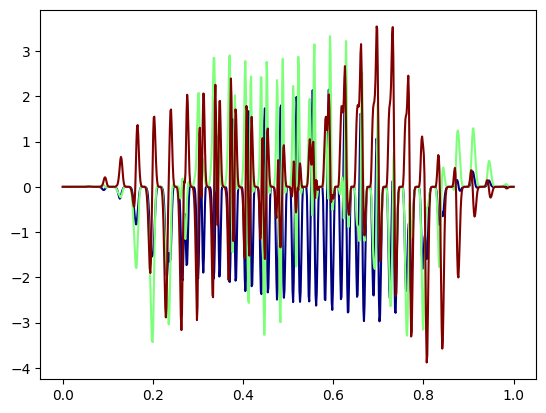

In [6]:
# Visualize our own functions. They are not very informative,
# Nevertheless, you can look at them
_ = plot(fpca.eigenfunctions)
plt.show()

(-0.5, 27.5, 27.5, -0.5)

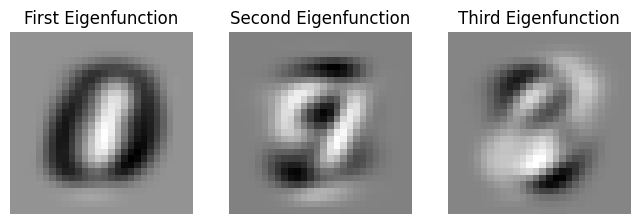

In [7]:
# We output the first 3 eigenfunctions separately to 
# have a more visual representation 
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
axes[0].imshow(fpca.eigenfunctions[0].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[0].set_title("First Eigenfunction")
axes[0].axis("off")

axes[1].imshow(fpca.eigenfunctions[1].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[1].set_title("Second Eigenfunction")
axes[1].axis("off")

axes[2].imshow(fpca.eigenfunctions[2].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[2].set_title("Third Eigenfunction")
axes[2].axis("off")

(-0.5, 27.5, 27.5, -0.5)

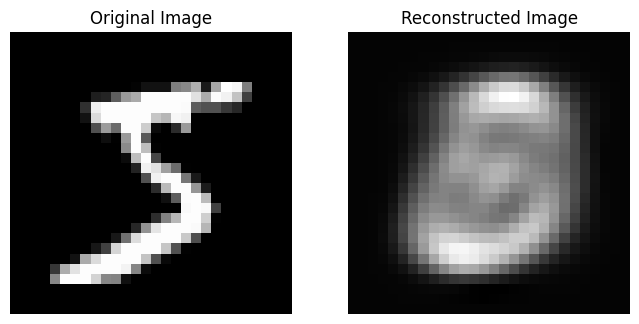

In [8]:
# Recover data from FPCA and output comparatively 
# the original MNIST image and the restored image 
X_train_reconstruct = fpca.inverse_transform(X_train_fpca)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0].reshape(28, 28), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")
    
axes[1].imshow(X_train_reconstruct[0].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

## Observations
As anticipated, using only three functional principal components (FPCs) fails to achieve high classification performance. This aligns with theoretical expectations - MNIST's complex digit variations require substantially more components to capture discriminative features. 

Nevertheless, it was interesting to see what kind of accuracy would result if you trimmed the information in the data that much.

In [9]:
# Performing classification with a classic SVM
clf = SVC(kernel='linear')
clf.fit(X_train_fpca, y_train)
y_pred = clf.predict(X_test_fpca)

# Let's evaluate the test accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of classification using FPCA: {accuracy:.4f}")

Accuracy of classification using FPCA: 0.4870


# Number of components equal to 10

In this case, we set the number of components equal to 10, on which further classification will be performed.

In [10]:
# Execute FPCA
fpca = UFPCA(n_components=10)
fpca.fit(fdata_train)

X_train_fpca = fpca.transform(fdata_train)
X_test_fpca = fpca.transform(fdata_test)

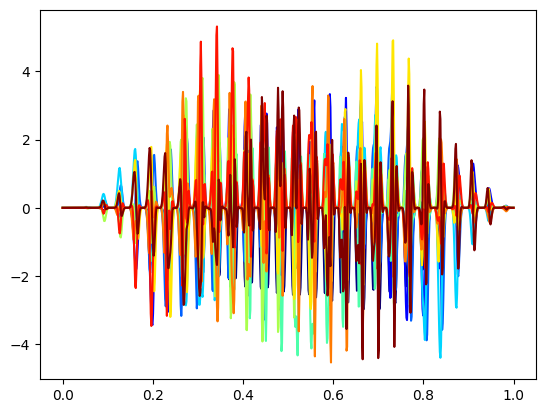

In [11]:

_ = plot(fpca.eigenfunctions)
plt.show()

(-0.5, 27.5, 27.5, -0.5)

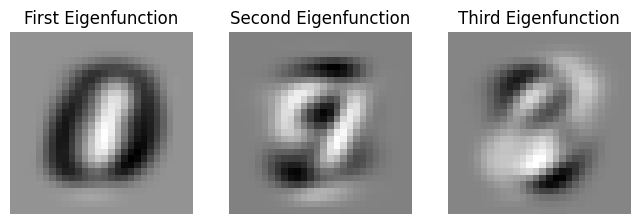

In [12]:
# We output the first 3 eigenfunctions separately to 
# have a more visual representation 
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
axes[0].imshow(fpca.eigenfunctions[0].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[0].set_title("First Eigenfunction")
axes[0].axis("off")

axes[1].imshow(fpca.eigenfunctions[1].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[1].set_title("Second Eigenfunction")
axes[1].axis("off")

axes[2].imshow(fpca.eigenfunctions[2].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[2].set_title("Third Eigenfunction")
axes[2].axis("off")

(-0.5, 27.5, 27.5, -0.5)

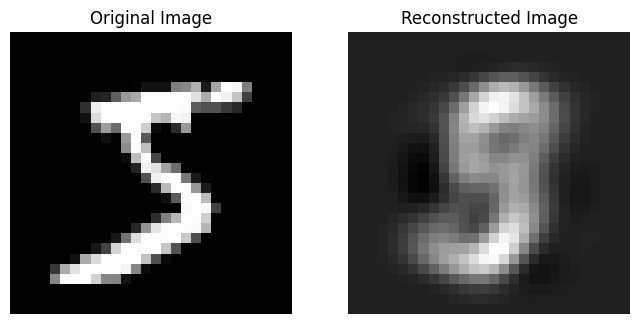

In [13]:
# Восстанавливаем из FPCA данные и выводим сравнительно 
# оригинальное изображение из MNIST и восстановленное 
X_train_reconstruct = fpca.inverse_transform(X_train_fpca)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0].reshape(28, 28), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")
    
axes[1].imshow(X_train_reconstruct[0].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

## Observations

Increasing the number of components from 3 to 10, as expected, leads to a strong increase in prediction quality: $ 0.8407 - 0.4870 = 0.3537. $ It is not surprising that digit images are not described by three components, however, it is rather unexpected that 10 feature components already leads to a good quality of the classifier - an accuracy of 0.84 is quite good.

In [14]:
# Performing classification with a classic SVM
clf = SVC(kernel='linear')
clf.fit(X_train_fpca, y_train)
y_pred = clf.predict(X_test_fpca)

# Let's evaluate the test accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of classification using FPCA: {accuracy:.4f}")

Accuracy of classification using FPCA: 0.8407


# Number of components equal to 30

In this case, we set the number of components equal to 30, on which further classification will be performed.

In [15]:
fpca = UFPCA(n_components=30)
fpca.fit(fdata_train)

X_train_fpca = fpca.transform(fdata_train)
X_test_fpca = fpca.transform(fdata_test)

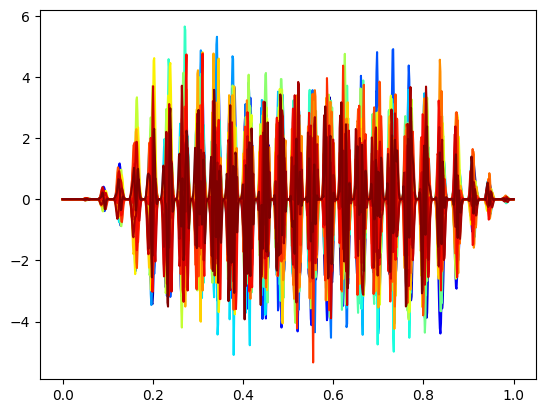

In [16]:
_ = plot(fpca.eigenfunctions)
plt.show()

(-0.5, 27.5, 27.5, -0.5)

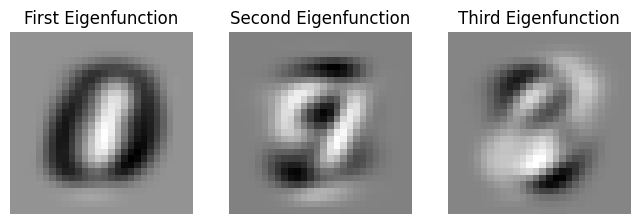

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
axes[0].imshow(fpca.eigenfunctions[0].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[0].set_title("First Eigenfunction")
axes[0].axis("off")

axes[1].imshow(fpca.eigenfunctions[1].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[1].set_title("Second Eigenfunction")
axes[1].axis("off")

axes[2].imshow(fpca.eigenfunctions[2].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[2].set_title("Third Eigenfunction")
axes[2].axis("off")

(-0.5, 27.5, 27.5, -0.5)

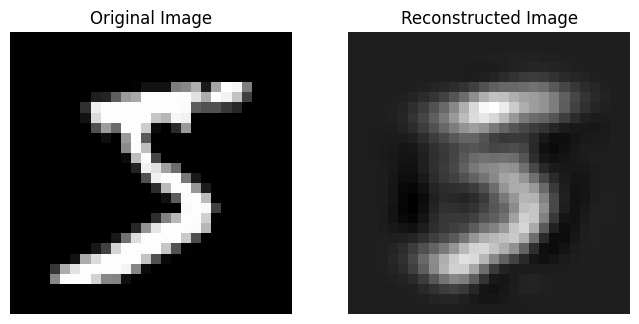

In [18]:
# Recover data from FPCA and output comparatively 
# the original MNIST image and the restored image 
X_train_reconstruct = fpca.inverse_transform(X_train_fpca)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0].reshape(28, 28), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")
    
axes[1].imshow(X_train_reconstruct[0].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

## Observations

The increase in accuracy when the number of components grows from 10 to almost 30 is still noticeable: $ 0.9142 - 0.8407 = 0.0735. $ We should assume that the real number of functional components describing the data is greater than 10, since the accuracy growth rate is quite satisfactory.

In [19]:

clf = SVC(kernel='linear')
clf.fit(X_train_fpca, y_train)
y_pred = clf.predict(X_test_fpca)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of classification using FPCA: {accuracy:.4f}")

Accuracy of classification using FPCA: 0.9142


# Adaptive number of components

In [20]:
# Perform FPCA so that the decomposition
# explains 85% of the variance in the data
fpca = UFPCA(n_components=0.85)
fpca.fit(fdata_train)

# Transform the data using FPCA
X_train_fpca = fpca.transform(fdata_train)
X_test_fpca = fpca.transform(fdata_test)

It is easy to see that the number of components is much higher than in the previous example. This number of eigenfunctions explains 85% of the variance in the training data

In [21]:
fpca.eigenfunctions

Functional data object with 59 observations on a 1-dimensional support.

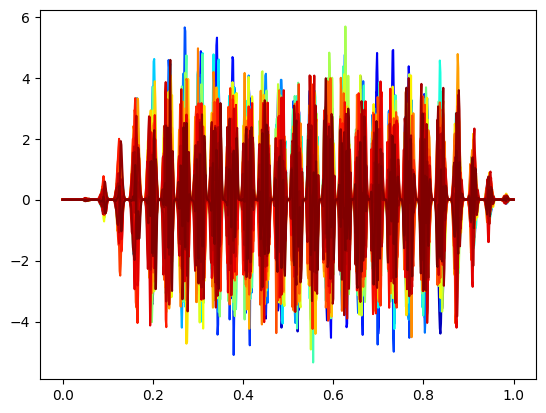

In [22]:
_ = plot(fpca.eigenfunctions)
plt.show()

(-0.5, 27.5, 27.5, -0.5)

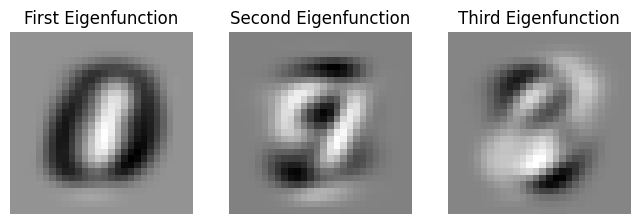

In [23]:
# Выводим отдельно первые 3 собственные функции, чтобы 
# иметь более наглядное представление 
fig, axes = plt.subplots(1, 3, figsize=(8, 3))
axes[0].imshow(fpca.eigenfunctions[0].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[0].set_title("First Eigenfunction")
axes[0].axis("off")

axes[1].imshow(fpca.eigenfunctions[1].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[1].set_title("Second Eigenfunction")
axes[1].axis("off")

axes[2].imshow(fpca.eigenfunctions[2].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[2].set_title("Third Eigenfunction")
axes[2].axis("off")

(-0.5, 27.5, 27.5, -0.5)

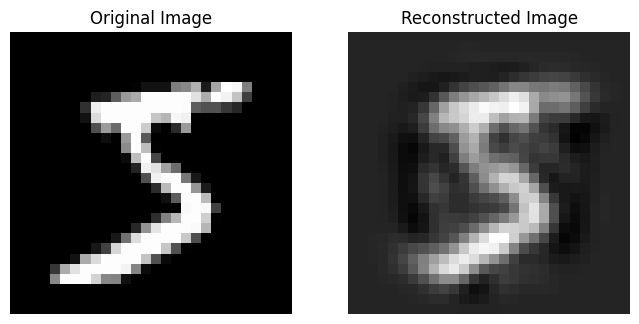

In [24]:
X_train_reconstruct = fpca.inverse_transform(X_train_fpca)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0].reshape(28, 28), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis("off")
    
axes[1].imshow(X_train_reconstruct[0].to_long().values[:, 2].reshape(28, 28), cmap='gray')
axes[1].set_title("Reconstructed Image")
axes[1].axis("off")

## Observations

The increase in accuracy as the number of components grows from 30 to almost 60 is already insignificant: $ 0.9287 - 0.9142 \approx 0.0145. $ This indicates that the number of functional components needed for a good explanation of the data and classification is actually in the range of 30-40, as the increase in accuracy slows down further.

In [25]:
clf = SVC(kernel='linear')
clf.fit(X_train_fpca, y_train)
y_pred = clf.predict(X_test_fpca)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of classification using FPCA: {accuracy:.4f}")

Accuracy of classification using FPCA: 0.9287


# Plot of accuracy vs. number of components 

Accuracy of classification using FPCA: 0.4474
Accuracy of classification using FPCA: 0.4870
Accuracy of classification using FPCA: 0.5949
Accuracy of classification using FPCA: 0.7061
Accuracy of classification using FPCA: 0.7684
Accuracy of classification using FPCA: 0.7943
Accuracy of classification using FPCA: 0.8216
Accuracy of classification using FPCA: 0.8271
Accuracy of classification using FPCA: 0.8407
Accuracy of classification using FPCA: 0.8421
Accuracy of classification using FPCA: 0.8648
Accuracy of classification using FPCA: 0.8760
Accuracy of classification using FPCA: 0.8913
Accuracy of classification using FPCA: 0.9028
Accuracy of classification using FPCA: 0.9118
Accuracy of classification using FPCA: 0.9142


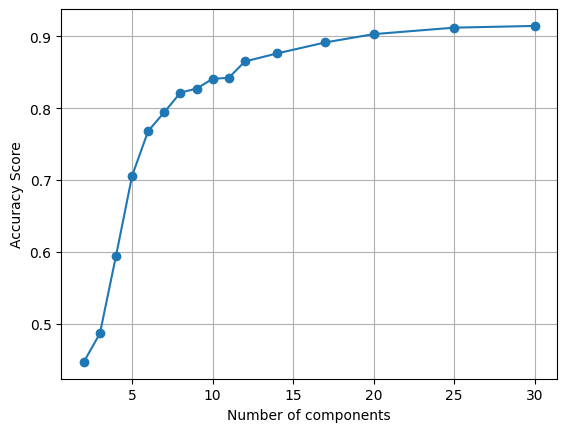

In [26]:
acc_list = []
y_pred_list = []
fpca_list = []
acc_list_x = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 17, 20, 25, 30]


for n_components in acc_list_x: 
 
  fpca = UFPCA(n_components=n_components)
  fpca.fit(fdata_train)

  X_train_fpca = fpca.transform(fdata_train)
  X_test_fpca = fpca.transform(fdata_test)
 
  clf = SVC(kernel='linear')
  clf.fit(X_train_fpca, y_train)
  y_pred = clf.predict(X_test_fpca)

  
  accuracy = accuracy_score(y_test, y_pred)
  print(f"Accuracy of classification using FPCA: {accuracy:.4f}")
  acc_list.append(accuracy)
  fpca_list.append(fpca)


plt.plot(acc_list_x, acc_list, 'o-')
plt.grid(True)
plt.ylabel('Accuracy Score')
plt.xlabel('Number of components')
plt.show()

# Conclusions

1) FPCA can significantly reduce the dimensionality of the data, when represented as functional, in tasks with real datasets such as MNIST,

2) However, the task of determining the required number of components can be challenging because the algorithm is memory intensive and, in this particular situation, could not perform a decomposition explaining > 85% of the variance in the data.